# ЛР-01: Комплектование аварийных энергетических наборов

## Worked example: military 01

Это полностью разобранный example. Его задача — показать образец оформления, логики решения и интерпретации результата.

## 1. Постановка кейса

Склад формирует базовые и усиленные аварийные энергетические наборы.

Обозначим:

- $x_1$ — количество базовых энергетических наборов;
- $x_2$ — количество усиленных энергетических наборов.

Целевая функция:

$$
\max z = 12x_1 + 9x_2
$$

Ограничения:

$$
4x_1 + 2x_2 \le 32
$$

$$
1x_1 + 2x_2 \le 18
$$

$$
x_1 \ge 0, \quad x_2 \ge 0
$$

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog


def feasible_vertices(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Находит кандидатов в вершины допустимой области для задачи с двумя переменными.

    Args:
        A: Матрица ограничений размера `(m, 2)`.
        b: Вектор правых частей.

    Returns:
        np.ndarray: Массив допустимых вершин без повторов.
    """
    candidates = [np.array([0.0, 0.0])]

    for row, rhs in zip(A, b):
        if row[0] > 0:
            candidates.append(np.array([rhs / row[0], 0.0]))
        if row[1] > 0:
            candidates.append(np.array([0.0, rhs / row[1]]))

    for i, j in itertools.combinations(range(len(A)), 2):
        matrix = np.vstack([A[i], A[j]])
        if abs(np.linalg.det(matrix)) > 1e-9:
            point = np.linalg.solve(matrix, np.array([b[i], b[j]], dtype=float))
            candidates.append(point)

    feasible = []
    for point in candidates:
        if np.all(point >= -1e-9) and np.all(A @ point <= b + 1e-9):
            feasible.append(np.maximum(point, 0.0))

    unique = []
    for point in feasible:
        if not any(np.allclose(point, saved, atol=1e-9) for saved in unique):
            unique.append(point)
    return np.array(unique, dtype=float)


A = np.array([[4, 2], [1, 2]], dtype=float)
b = np.array([32, 18], dtype=float)
objective = np.array([12, 9], dtype=float)

vertices = feasible_vertices(A, b)
values = vertices @ objective
vertices_df = pd.DataFrame(vertices, columns=['x1', 'x2'])
vertices_df['z'] = values
display(vertices_df.round(4))

,x1,x2,z
0,0.0000,0.0000,0.0
1,8.0000,0.0000,96.0
2,0.0000,9.0000,81.0
3,4.6667,6.6667,116.0


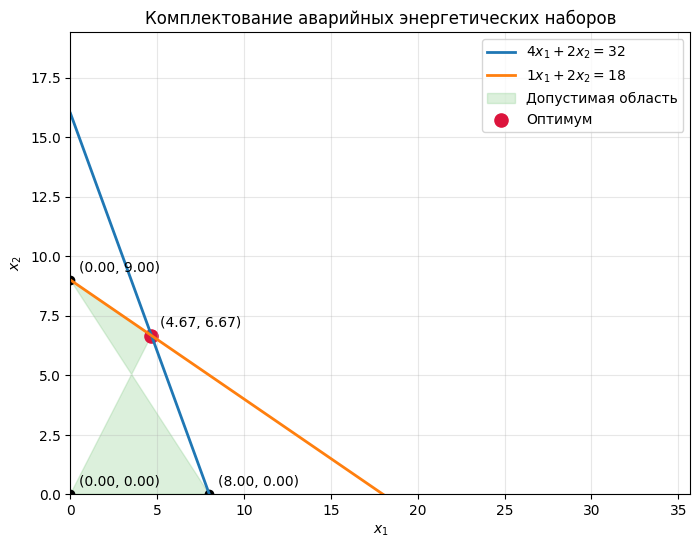

Лучшая вершина по геометрическому анализу: [4.66666667 6.66666667]
Значение z в ней: 116.0


In [2]:
# Строим ту же задачу геометрически, чтобы увидеть допустимую область глазами.
x = np.linspace(0, max(32, 18) + 2, 400)
line_1 = (32 - 4 * x) / 2
line_2 = (18 - 1 * x) / 2

best_idx = int(np.argmax(values))
best_point = vertices[best_idx]
best_value = values[best_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, line_1, label=r'$4x_1 + 2x_2 = 32$', linewidth=2)
ax.plot(x, line_2, label=r'$1x_1 + 2x_2 = 18$', linewidth=2)
ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.25, color='#74c476', label='Допустимая область')
ax.scatter(vertices[:, 0], vertices[:, 1], color='black')
ax.scatter(best_point[0], best_point[1], color='crimson', s=90, label='Оптимум')

for vx, vy in vertices:
    ax.annotate(f'({vx:.2f}, {vy:.2f})', (vx, vy), textcoords='offset points', xytext=(6, 6))

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Комплектование аварийных энергетических наборов')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print('Лучшая вершина по геометрическому анализу:', best_point)
print('Значение z в ней:', best_value)

In [3]:
# Теперь подтверждаем ответ через linprog.
c = -objective
result = linprog(c, A_ub=A, b_ub=b, bounds=[(0, None), (0, None)], method='highs')

print('success =', result.success)
print('message =', result.message)
print('x* =', result.x)
print('z_max =', -result.fun)

assert result.success
assert np.allclose(result.x, best_point)
assert np.isclose(-result.fun, best_value)

success = True
message = Optimization terminated successfully. (HiGHS Status 7: Optimal)
x* = [4.66666667 6.66666667]
z_max = 116.0


## 2. Как интерпретировать результат

- найденная вершина даёт лучший допустимый план;
- ни один другой допустимый угол не даёт большее значение цели;
- проверка через `linprog` совпала с геометрическим анализом.

### Что важно проговорить в выводе

1. Какие ограничения оказались определяющими для оптимума.
2. Почему решение лежит именно в вершине допустимой области.
3. Какой практический смысл имеют значения $x_1^*$ и $x_2^*$.